In [ ]:
i!pip install langchain
!pip install langchain_google_genai
!pip install langchain_classic

In [ ]:
from google.colab import userdata
gm = userdata.get('HH')

In [ ]:
import os
os.environ["GOOGLE_API_KEY"] = gm

In [ ]:
import langchain
import langchain_classic
from langchain_google_genai import GoogleGenerativeAI,ChatGoogleGenerativeAI

In [ ]:
from langchain_core.prompts import SystemMessagePromptTemplate,HumanMessagePromptTemplate,ChatPromptTemplate

In [ ]:
cpt = ChatPromptTemplate.from_messages([SystemMessagePromptTemplate.from_template("you are havinga 10 years of experience in writing nd generatinga story"),
                                  HumanMessagePromptTemplate.from_template("based on the genre:{genre} generarte a story")])

In [ ]:
prompt = cpt.format(genre='adventure')

In [ ]:
model = ChatGoogleGenerativeAI(model = "gemini-2.5-flash-lite")

In [ ]:
response = model.invoke(prompt)

In [ ]:
response.content

'Alright, settle in, and let me spin you a yarn. Ten years of weaving tales, and adventure is a genre that always gets my blood pumping. Here\'s a story, fresh from the loom:\n\n**The Whispering Sands of Xylos**\n\nThe desert sun beat down on Elara\'s face, a relentless hammer against her weathered skin. For weeks, the vast, ochre expanse of Xylos had been her unforgiving canvas. Her compass, a tarnished brass orb passed down from her grandfather, spun erratically, a testament to the strange magnetic anomalies that plagued this forgotten land. Elara wasn\'t chasing gold or glory; she was chasing a whisper, a legend of the Sunstone, an artifact said to hold the very essence of daylight, capable of banishing any shadow.\n\nHer companion, a gruff, one-eyed desert hawk named Zephyr, screeched from his perch on her shoulder, his gaze fixed on a shimmering distortion on the horizon. "Trouble, Elara," his raspy voice, a gift of some ancient desert magic, seemed to echo in her mind.\n\n"I know

In [ ]:
from langchain_core.output_parsers import StrOutputParser

In [ ]:
strp = StrOutputParser()

In [ ]:
strp.parse(response.content)

'Alright, gather \'round, and let old Silas spin you a yarn. Ten years I\'ve been weaving tales, and adventure, ah, that\'s the thread that runs through them all. So, let\'s dive in.\n\n***\n\nThe air in the Sunken City of Eldoria tasted of salt and forgotten dreams. Elara, her leather boots crunching on the barnacle-encrusted cobblestones, felt the weight of centuries press down on her. Sunlight, fractured by the murky depths, painted ethereal shafts through the drowned plazas, illuminating colossal statues of beings long turned to stone. Her companion, a grizzled dwarf named Borin, grumbled beside her, his beard a tangled testament to countless underground expeditions.\n\n"Remind me again, lass," Borin rasped, his voice echoing strangely in the watery silence, "why we\'re spelunking in a drowned metropolis when there\'s perfectly good dry caves filled with gold?"\n\nElara adjusted the strap of her satchel, her eyes scanning the intricate carvings on a crumbling archway. "Because, Bor

#chains

In [ ]:
from langchain_classic.chains import LLMChain,SequentialChain

In [ ]:
chain = LLMChain(prompt=cpt,llm=model,output_parser=strp)

In [ ]:
out = chain.run(genre='adventure')

In [ ]:

out

'The biting wind whipped Elara\'s fiery red hair across her face, stinging her eyes. Below, the jagged peaks of the Serpent\'s Tooth mountains pierced the bruised twilight sky, a formidable barrier that had claimed the lives of countless adventurers. But Elara wasn\'t just any adventurer; she was a seeker, a cartographer of the lost, and the whispers of the Sunken City of Aethelgard had finally lured her to this desolate edge of the world.\n\nHer worn leather boots crunched on loose scree as she adjusted the straps of her pack, its canvas bulging with ropes, rations, and her precious collection of ancient maps. The legend spoke of a city swallowed by the earth millennia ago, a place of unimaginable riches and forgotten knowledge, guarded by trials that tested the very core of a person\'s spirit. Many had sought it, drawn by the allure of gold and glory, but none had ever returned.\n\nHer guide, a grizzled, one-eyed man named Kael, pointed a gnarled finger towards a narrow crevice that 

In [ ]:
chain1 = LLMChain(prompt=cpt,llm=model,output_parser=strp,output_key='story')

In [ ]:
cpt1 = ChatPromptTemplate.from_messages([SystemMessagePromptTemplate.from_template("you are havinga 10 years of experience in generattin a question on a story"),
                                  HumanMessagePromptTemplate.from_template("based on the story:{story} generarte a 4 to 6questions ")])

In [ ]:
chain2 = LLMChain(prompt=cpt1,llm=model,output_parser=strp,output_key='question')

In [ ]:
sc = SequentialChain(chains=[chain1,chain2],input_variables=['genre'],output_variables=['question'])

In [ ]:
output = sc.run(genre='romantaic')

In [ ]:
print(output)

Here are 4 to 6 questions based on the story "The Last Chapter":

1.  How did Liam's initial perception of Elara and "The Last Chapter" evolve throughout their interactions, and what specific moments or observations contributed to this change?
2.  Beyond the obvious conflict of demolition versus preservation, what underlying themes or values did Elara and Liam represent, and how did their developing relationship bridge these differences?
3.  Consider the symbolic significance of the books Elara and Liam share, such as *Pride and Prejudice* and *Dune*. What do these specific titles reveal about their characters and their budding connection?
4.  The story presents a compromise for "The Last Chapter." What does this resolution suggest about the possibility of integrating old traditions with modern progress, and how does it reflect the characters' personal growth?
5.  In what ways does the setting of "The Last Chapter" contribute to the atmosphere and the development of the central relatio

#runnables

In [ ]:
from langchain_core.runnables import RunnableSequence

In [ ]:
chain = RunnableSequence(cpt,model,strp)

In [ ]:
chain.invoke("adventure")

'The biting wind whipped Elara’s auburn hair across her face, stinging her eyes. Below her, the treacherous Serpent’s Pass snaked its way through jagged, snow-capped peaks, a ribbon of ice and peril. Her breath plumed in the frigid air, a stark contrast to the fiery determination burning in her chest. For years, the whispered legends of the Sunstone, a jewel said to hold the warmth of a thousand summers, had been mere campfire tales. But Elara, a cartographer by trade and an adventurer by heart, had pieced together fragments of ancient texts, obscure maps, and the ramblings of dying explorers. She was convinced the Sunstone wasn\'t a myth; it was real, hidden somewhere in the unforgiving heart of the Frostfall Mountains.\n\nHer companion, a gruff but loyal mountain guide named Borin, grunted beside her. His weathered face was etched with concern. "This is madness, Elara. The pass is notorious. Many have tried, none have returned."\n\nElara tightened her grip on her walking stick, its i

In [ ]:
chain0 = cpt|model|strp #sequencial runnables

In [ ]:
chain0.invoke("adventure")

'The salt spray stung Elara\'s cheeks as the *Sea Serpent* plunged through another towering wave. For weeks, they\'d been chasing whispers of the Sunken City of Aethelgard, a legend spoken only in hushed tones by grizzled sailors and madmen. Most dismissed it as a myth, a mariner\'s fever dream. But Elara, with her insatiable thirst for discovery and a tattered, cryptic map inherited from her grandfather, believed.\n\nBeside her, Jax, a burly, silent man with forearms like oak trunks, adjusted the tiller, his weathered face a mask of concentration. His loyalty was as steadfast as his grip on the wood, a silent promise to protect Elara on these treacherous voyages. Across the deck, Lyra, the ship\'s nimble navigator, traced constellations on a parchment, her brow furrowed in concentration. She was the calm in Elara\'s storm, the logic to her daring.\n\n"Anything, Lyra?" Elara shouted over the wind\'s roar.\n\nLyra shook her head, her dark braids whipping around her face. "The stars are…

In [ ]:

chain1= cpt|model|strp|cpt1|model|strp

In [ ]:
chain1.invoke("adventure")

"Here are 4 to 6 questions based on the story you provided:\n\n1.  What was the primary motivation for Elara and Borin's perilous journey into the Whispering Peaks?\n2.  How did the alignment of the twin moons play a crucial role in revealing the entrance to the Sunstone's resting place?\n3.  Describe the K'tharr and the reason they were guarding the Sunstone.\n4.  What was Elara's strategy for de-escalating the conflict with the K'tharr, and how did it differ from Borin's approach?\n5.  What conditions did the K'tharr leader set for Elara and Borin to borrow the Sunstone's warmth, and what was the potential consequence of failing to meet them?\n6.  Beyond the immediate restoration of Aethelgard's land, what does Elara understand to be the true, ongoing challenge for her people?"

In [ ]:
from IPython.display import Image,display

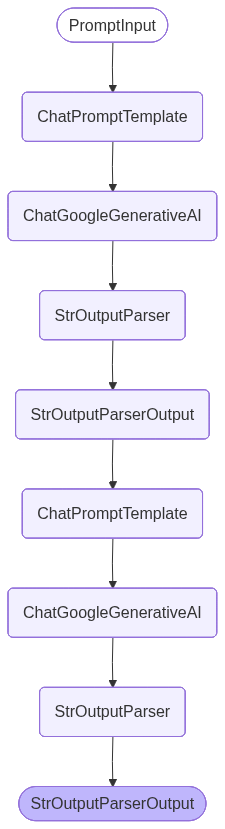

In [ ]:
graph = chain1.get_graph()

display(Image(graph.draw_mermaid_png()))

 RunnableSequence

In [ ]:
model = ChatGoogleGenerativeAI(model = "gemini-2.5-flash-lite")

In [ ]:
cpt = ChatPromptTemplate.from_messages([SystemMessagePromptTemplate.from_template("you are havinga 10 years of experience in writing nd generatinga story"),
                                  HumanMessagePromptTemplate.from_template("based on the genre:{genre} generarte a story")])

In [ ]:
from langchain_core.runnables import RunnableSequence

In [ ]:
sc = RunnableSequence(cpt,model,strp) #cpt|model|strp

In [ ]:
response = sc.invoke({"genre":"adventure"})

In [ ]:
print(response)

The salt spray kissed Elara’s face, a familiar greeting that never failed to stir the wildness in her soul. Her weathered hands, calloused from years of gripping rope and wielding a cutlass, tightened their hold on the ship’s wheel. The Sea Serpent, her beloved brigantine, sliced through the sapphire waves of the Serpent’s Teeth archipelago, each creak and groan of her timbers a song of a life lived on the edge of the world.

For years, whispers of the Sunstone, a legendary artifact said to hold the light of a thousand dawns, had danced in the taverns and marketplaces of every port she’d visited. They spoke of its power to heal, to illuminate the darkest corners, and to bestow unimaginable fortune upon its wielder. Most dismissed it as a myth, a sailor’s fancy. But Elara, with her insatiable thirst for the unknown and a heart that beat in rhythm with the ocean’s untamed pulse, believed.

Her current quest had led her to this treacherous chain of islands, a place where jagged volcanic p

In [ ]:
cpt = ChatPromptTemplate.from_messages([SystemMessagePromptTemplate.from_template("you are havinga {years} years of experience in writing nd generatinga story"),
                                  HumanMessagePromptTemplate.from_template("based on the genre:{genre} generarte a story")])

In [ ]:
sc = RunnableSequence(cpt,model,strp) #cpt|model|strp

In [ ]:
sc.invoke({"years":10,"genre":"romantic"})

'The scent of old paper and brewing coffee always made Elara’s heart flutter. It was the smell of her sanctuary, "The Gilded Page," a cozy bookstore tucked away on a cobblestone street that time seemed to have forgotten. Elara, with her perpetually ink-stained fingers and a smile that could melt glaciers, had inherited the shop from her grandmother, a woman who believed stories were the most potent form of magic.\n\nOne blustery autumn afternoon, as the wind rattled the shop windows, the bell above the door chimed, announcing a new arrival. He was tall, with a mop of unruly dark hair that looked like it had been styled by the very wind outside, and eyes the color of a storm-tossed sea. He carried a worn leather satchel and a quiet intensity that drew Elara in immediately.\n\n"Looking for anything in particular?" Elara asked, her voice a soft melody against the rustling pages.\n\nHe looked around, his gaze lingering on the towering shelves. "I\'m not entirely sure," he admitted, a sligh

In [ ]:
cpt1 = ChatPromptTemplate.from_messages([SystemMessagePromptTemplate.from_template("you are havinga {years} years of experience in writing nd generatinga story"),
                                  HumanMessagePromptTemplate.from_template("based on the genre:{genre} generarte a story")])
cpt2 = ChatPromptTemplate.from_messages([SystemMessagePromptTemplate.from_template("you are having a 10 years of experience in giving rating  on a story"),
                                  HumanMessagePromptTemplate.from_template("based on the story:{story} rate it outoff 5 best is 5 worst is 1")])

In [ ]:
sc1 = cpt1|model|strp|cpt2|model|strp

In [ ]:
sc1.invoke({'years':15,"genre":'romantic'})

'Here\'s my rating of the story, based on my 10 years of experience:\n\n**Rating: 4.5 out of 5**\n\n**Reasoning:**\n\nThis is a charming and well-executed contemporary romance. Here\'s a breakdown of why it earns a high score:\n\n*   **Atmosphere and Setting (5/5):** The opening immediately establishes a strong sense of place. The "scent of old paper and brewing coffee," the "quaint bookstore," and the "cobblestone street" create an inviting and romantic atmosphere that perfectly complements the story\'s themes. "The Last Chapter" feels like a character in itself.\n*   **Character Development (4/5):** Elara is a relatable protagonist, her quiet life and hidden dreams resonating with many readers. Liam is introduced as a compelling contrast, his vibrant energy and artistic nature adding an intriguing dynamic. Their individual vulnerabilities and desires are revealed gradually, making their connection feel earned.\n*   **Pacing and Plot Progression (4/5):** The story unfolds at a gentle,

In [ ]:
from langchain_core.runnables import RunnablePassthrough

In [ ]:
rs = RunnablePassthrough()

In [ ]:
rs.invoke("chakravardhan")

'chakravardhan'

In [ ]:
sc3 = RunnablePassthrough.assign(story = RunnableSequence(cpt1,model,strp))|cpt2|model|strp

In [ ]:
sc3 = RunnablePassthrough.assign(story = RunnableSequence(cpt1,model,strp))|cpt2|model|strp

In [ ]:
sc3.invoke({'years':15,"genre":'romantic'})

'Here\'s my rating of the story, based on my 10 years of experience:\n\n**Rating: 4.5 out of 5**\n\n**Reasoning:**\n\nThis is a charming and well-crafted short story that hits all the right notes for a sweet romance.\n\n**What I loved:**\n\n*   **Atmosphere:** The description of the bookstore is exquisite. The "scent of old paper and brewing coffee" immediately draws you in and creates a tangible sense of place. It feels like a character in itself.\n*   **Character Development (Concise):** Elara is presented as a relatable and sympathetic protagonist. Her love for books and her quiet nature are established effectively. Liam is also intriguing, his "nervous energy" and "stormy sea" eyes creating a sense of mystery and depth.\n*   **Pacing:** The story unfolds at a gentle, engaging pace. The initial meeting feels natural, and the development of their connection through shared interests and Liam\'s regular visits feels earned.\n*   **Dialogue:** The dialogue is subtle and meaningful. The 

In [ ]:
cpt1 = ChatPromptTemplate.from_messages([SystemMessagePromptTemplate.from_template("you are havinga {years} years of experience in writing nd generatinga story"),
                                  HumanMessagePromptTemplate.from_template("based on the genre:{genre} generarte a story")])
cpt2 = ChatPromptTemplate.from_messages([SystemMessagePromptTemplate.from_template("you are having a {exp} years of experience in giving rating  on a story"),
                                  HumanMessagePromptTemplate.from_template("based on the story:{story} rate it outoff 5 best is 5 worst is 1")])

In [ ]:
sc2 = RunnableSequence(cpt1,model,strp,cpt2,model,strp)

In [ ]:
sc2.invoke({'years':15,"genre":'romantic',"exp":15})

'This is a lovely, heartwarming story with a classic romantic arc. Here\'s my rating:\n\n**4.5 out of 5 stars**\n\n**Here\'s why:**\n\n*   **Strengths:**\n    *   **Atmosphere:** The bookstore setting is beautifully established with sensory details (scent of paper and coffee, dusty windows, warm glow of lamps). It immediately creates a cozy and inviting atmosphere.\n    *   **Character Contrast:** Elara and Liam are well-contrasted, making their initial interactions and eventual connection feel organic. Liam\'s vibrancy against Elara\'s quietude is a classic and effective trope.\n    *   **Pacing:** The story builds nicely. The initial interactions are subtle, leading to deeper conversations and then to the romantic confession. It doesn\'t rush the development of their feelings.\n    *   **Dialogue:** The dialogue, especially their conversation about "Wuthering Heights" and modern love, is a highlight. It reveals character and moves the plot forward effectively.\n    *   **Emotional Re

In [ ]:
sc3 = RunnablePassthrough.assign(story = RunnableSequence(cpt1,model,strp))|RunnablePassthrough.assign(exp=lambda response:response['years'])|cpt2|model|strp

In [ ]:
response = sc3.invoke({'years':15,"genre":'romantic'})

In [ ]:
response

'As an experienced story rater, I\'ve had the pleasure of reading countless narratives, and "The Last Chapter" certainly holds its own. Here\'s my rating:\n\n**Rating: 4.5 out of 5**\n\nHere\'s my breakdown of why:\n\n**Strengths:**\n\n*   **Atmosphere and Setting (5/5):** The story excels in creating a vivid and evocative atmosphere. The scent of old paper and coffee, the cobblestone street, and the cozy bookstore are all masterfully described, immediately drawing the reader into Anya\'s world. "The Last Chapter" feels like a character in itself.\n*   **Character Development (4/5):** Anya is a relatable and charming protagonist. Her passion for books and her sanctuary is palpable. Liam is introduced effectively, and his quiet intensity and thoughtful nature make him an appealing counterpart. Their connection feels natural and earned.\n*   **Pacing and Plot Progression (4/5):** The story moves at a gentle, steady pace that suits its romantic and cozy theme. The development of Anya and 

In [ ]:
RunnablePassthrough.assign(exp=lambda response:response['years'])

RunnableAssign(mapper={
  exp: RunnableLambda(lambda response: response['years'])
})

In [ ]:
response

'As an experienced story rater, I\'ve had the pleasure of reading countless narratives, and "The Last Chapter" certainly holds its own. Here\'s my rating:\n\n**Rating: 4.5 out of 5**\n\nHere\'s my breakdown of why:\n\n**Strengths:**\n\n*   **Atmosphere and Setting (5/5):** The story excels in creating a vivid and evocative atmosphere. The scent of old paper and coffee, the cobblestone street, and the cozy bookstore are all masterfully described, immediately drawing the reader into Anya\'s world. "The Last Chapter" feels like a character in itself.\n*   **Character Development (4/5):** Anya is a relatable and charming protagonist. Her passion for books and her sanctuary is palpable. Liam is introduced effectively, and his quiet intensity and thoughtful nature make him an appealing counterpart. Their connection feels natural and earned.\n*   **Pacing and Plot Progression (4/5):** The story moves at a gentle, steady pace that suits its romantic and cozy theme. The development of Anya and 

In [ ]:
sc3 = RunnablePassthrough.assign(story = RunnableSequence(cpt1,model,strp))|RunnablePassthrough.assign(exp=lambda response:response['years'])|RunnablePassthrough.assign(output=cpt2|model|strp)

In [ ]:
final = sc3.invoke({"years":15,"genre":"romantic"})

In [ ]:
final

{'years': 15,
 'genre': 'romantic',
 'story': 'The scent of old paper and brewing coffee was Elara’s sanctuary. Tucked away in the back corner of "The Last Chapter," her small, independent bookstore, she felt most herself. Today, however, the quiet hum of the shop was punctuated by a nervous flutter in her chest. It had been a week since he’d first walked in, a whirlwind of rain and apologies for nearly knocking over a display of classic poetry.\n\nHis name was Liam. He had eyes the color of a stormy sea, a smile that creased at the corners, and a habit of running a hand through his perpetually disheveled dark hair when he was thinking. He was a writer, he’d told her, struggling with a deadline for his debut novel. He’d bought a worn copy of "Wuthering Heights" and promised to return.\n\nAnd he had. Every few days, Liam would appear, browsing the shelves with an intensity that mirrored her own love for stories. They\'d exchange shy smiles, then hesitant conversations about favorite aut

**runnable lambda**

In [ ]:
!pip install langchain
!pip install langchain_google_genai

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.1/53.1 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 719.1/719.1 kB 29.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 234.9/234.9 kB 19.7 MB/s eta 0:00:00
  Attempting uninstall: google-auth
    Found existing installation: google-auth 2.43.0
    Uninstalling google-auth-2.43.0:
      Successfully uninstalled google-auth-2.43.0
  Attempting uninstall: google-genai
    Found existing installation: google-genai 1.55.0
    Uninstalling google-genai-1.55.0:
      Successfully uninstalled google-genai-1.55.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires google-auth==2.43.0, but you have google-auth 2.47.0 which is incompatible.


In [ ]:
from google.colab import userdata
gm = userdata.get('HH')

In [ ]:
import os
os.environ["GOOGLE_API_KEY"] = gm

In [ ]:
import langchain


In [ ]:
from langchain_google_genai import GoogleGenerativeAI,ChatGoogleGenerativeAI
from langchain_core.output_parsers import StrOutputParser

In [ ]:
from langchain_core.prompts import ChatPromptTemplate,HumanMessagePromptTemplate,SystemMessagePromptTemplate

In [ ]:
cpt = ChatPromptTemplate.from_messages([SystemMessagePromptTemplate.from_template("you are havinga 10 years of experience in writing nd generatinga story"),
                                  HumanMessagePromptTemplate.from_template("based on the genre:{genre} generarte a story")])

In [ ]:
cpt

ChatPromptTemplate(input_variables=['genre'], input_types={}, partial_variables={}, messages=[SystemMessagePromptTemplate(prompt=PromptTemplate(input_variables=[], input_types={}, partial_variables={}, template='you are havinga 10 years of experience in writing nd generatinga story'), additional_kwargs={}), HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['genre'], input_types={}, partial_variables={}, template='based on the genre:{genre} generarte a story'), additional_kwargs={})])

In [ ]:
model1 = ChatGoogleGenerativeAI(model = "gemini-3-flash-preview")

In [ ]:
strp = StrOutputParser()

In [ ]:
from langchain_core.runnables import RunnableLambda,RunnableSequence,RunnablePassthrough

In [ ]:
sw = RunnableSequence(cpt,model1,strp)

In [ ]:
def ch_co(x):
  return len(x.split())

In [ ]:
ch_co = RunnableLambda(ch_co)

In [ ]:
ch_co

RunnableLambda(ch_co)

In [ ]:
sw = RunnableSequence(cpt,model1,strp,ch_co)

In [ ]:
ou = sw.invoke({'genre':'advanture'})

In [ ]:
ou

863

In [ ]:
# with out converting the runnables sequence
sw = RunnableSequence(cpt,model1,strp,lambda x:len(x.split())) # intinaly its undestad its a runnable

In [ ]:
ou = sw.invoke({'genre','advanture'})

In [ ]:
ou

731

In [ ]:
def ch_co(x):
  return len(x.split())

In [ ]:
sw = RunnableSequence(cpt,model1,strp,ch_co)

In [ ]:
ou = sw.invoke({'genre':'advanture'})

In [ ]:
ou

1079

In [ ]:
m3 = RunnablePassthrough.assign(story=RunnableSequence(cpt,model1,strp))|RunnablePassthrough.assign(word = lambda x:len(x['story'].split()))

In [ ]:
m3.invoke({'genre':'advanture'})

{'genre': 'advanture',
 'story': 'With ten years of narrative crafting under my belt, I know that a great adventure isn’t just about the destination—it’s about the cost of the journey and the "ticking clock" that keeps the reader’s heart hammering.\n\nHere is an original adventure story titled **"The Skeleton of Aethelgard."**\n\n***\n\nThe fog didn’t just lift; it exhaled. \n\nSilas Thorne stood at the prow of the *Whispering Crow*, his hand white-knuckled on the brass railing. Ahead, rising from the churning grey of the Midnight Sea like a jagged tooth, was Aethelgard. It was an island that shouldn\'t exist—a landmass that appeared on no modern charts, visible only when the three moons of the solstice aligned to pull the tides to their lowest ebb.\n\n"Twelve hours, Silas," Captain Vane barked from the helm, her voice raspy from years of salt and smoke. "The tide returns at dawn. If you aren’t back on this pier by the time the first wave hits the cliffs, I’m sailing. I won’t lose my s

**runnable** **parllel**

In [ ]:
from langchain_core.runnables import RunnableParallel

In [ ]:
rp = RunnableParallel(o1=lambda x:x['x']+1,o2=lambda x:x['x']+2,o3=lambda x:x['x']+3)

In [ ]:
rp.invoke({'x':10})

{'o1': 11, 'o2': 12, 'o3': 13}

In [ ]:
cpt1 = ChatPromptTemplate.from_messages([SystemMessagePromptTemplate.from_template("you are havinga 10 years of experience in generating the mcq"),
                                  HumanMessagePromptTemplate.from_template("based on the story:{story} generarte a 10 mcq")])

In [ ]:
cpt2 = ChatPromptTemplate.from_messages([SystemMessagePromptTemplate.from_template("you are havinga 10 years of experience in generating the question and answer"),
                                  HumanMessagePromptTemplate.from_template("based on the story:{story} generarte a 10 question and answers")])

In [ ]:
cpt3 = ChatPromptTemplate.from_messages([SystemMessagePromptTemplate.from_template("you are havinga 10 years of experience in writing nd generatinga fill in the blanks"),
                                  HumanMessagePromptTemplate.from_template("based on the story:{story} generarte 10 fill in the blanks")])

In [ ]:
RunnablePassthrough.assign(story = RunnableSequence(cpt,model1,strp))

RunnableAssign(mapper={
  story: ChatPromptTemplate(input_variables=['genre'], input_types={}, partial_variables={}, messages=[SystemMessagePromptTemplate(prompt=PromptTemplate(input_variables=[], input_types={}, partial_variables={}, template='you are havinga 10 years of experience in writing nd generatinga story'), additional_kwargs={}), HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['genre'], input_types={}, partial_variables={}, template='based on the genre:{genre} generarte a story'), additional_kwargs={})])
         | ChatGoogleGenerativeAI(profile={'max_input_tokens': 1048576, 'max_output_tokens': 65536, 'image_inputs': True, 'audio_inputs': True, 'pdf_inputs': True, 'video_inputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'image_url_inputs': True, 'image_tool_message': True, 'tool_choice': True}, google_api_key=SecretStr('**********'), model='gemini

In [ ]:
RunnableParallel(mcq=RunnableSequence(cpt1,model1,strp),quiz=RunnableSequence(cpt2,model1,strp),fil=RunnableSequence(cpt3,model1,strp))

{
  mcq: ChatPromptTemplate(input_variables=['story'], input_types={}, partial_variables={}, messages=[SystemMessagePromptTemplate(prompt=PromptTemplate(input_variables=[], input_types={}, partial_variables={}, template='you are havinga 10 years of experience in generating the mcq'), additional_kwargs={}), HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['story'], input_types={}, partial_variables={}, template='based on the story:{story} generarte a 10 mcq'), additional_kwargs={})])
       | ChatGoogleGenerativeAI(profile={'max_input_tokens': 1048576, 'max_output_tokens': 65536, 'image_inputs': True, 'audio_inputs': True, 'pdf_inputs': True, 'video_inputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'image_url_inputs': True, 'image_tool_message': True, 'tool_choice': True}, google_api_key=SecretStr('**********'), model='gemini-3-flash-preview', temperature=1.0,

In [ ]:
app = RunnablePassthrough.assign(story = RunnableSequence(cpt,model1,strp))|RunnableParallel(mcq=RunnableSequence(cpt1,model1,strp),quiz=RunnableSequence(cpt2,model1,strp),fil=RunnableSequence(cpt3,model1,strp))

In [ ]:
o= app.invoke({'genre':'adventure'})

In [ ]:
print(o['quiz'])

Drawing from a decade of experience in narrative analysis and educational assessment, I have crafted these 10 questions to evaluate comprehension, character motivation, and the unique world-building mechanics found in "The Echo of the Glass Desert."

### Assessment: The Echo of the Glass Desert

**1. Question:** What is unique about the composition of the Shimmering Wastes, and why does this make sound particularly dangerous?
**Answer:** The desert is composed of pulverized obsidian and volcanic glass rather than sand. Sound is dangerous because the glass formations are tuned to specific pitches; a loud noise can trigger a "Glass-Slide," which is an avalanche of razor-sharp shards.

**2. Question:** What is the "ticking clock" or the primary motivation driving Kaelen to complete this mission?
**Answer:** Kaelen must find the Resonance Stone to unlock the irrigation vaults of the lower city. If he fails, the city will die of thirst by the arrival of the next eclipse.

**3. Question:** B

In [ ]:
from langchain_core.runnables import RunnableBranch

In [ ]:
def f1(x):
  return 'even'

In [ ]:
def f2(x):
  return 'odd'

In [ ]:
rb = RunnableBranch((lambda x:x['x']%2==0,f1),f2)

In [ ]:
rb.invoke({'x':10})

'even'

In [ ]:
cpt = ChatPromptTemplate.from_messages([SystemMessagePromptTemplate.from_template("you are havinga 10 years of experience in SUMMARING TH E STORY"),
                                  HumanMessagePromptTemplate.from_template("based on the story:{story} SYMMARIZE THE STORY IN 2 STENTENCE")])

In [ ]:
rb = RunnableBranch((lambda x:len(x['story'].split())<=10,RunnablePassthrough()),RunnableSequence(cpt,model1,strp))

In [ ]:
rb.invoke({'story':'i like a lof of advanture to do a best of the a'})

'As an expert summarizer with a decade of experience in distilling narratives down to their essence, here is a two-sentence summary based on the text provided:\n\nThe narrator expresses a profound passion for seeking out thrilling adventures and embracing the excitement of the unknown. Driven by a desire for excellence, they commit to performing at their absolute best throughout every challenge they encounter.'

In [ ]:
import langchain
from langchain_core.runnables import RunnableGenerator

In [ ]:
def f1(x):
  x=str(x)
  for word in x.split():
    yield word


In [ ]:
r0 = RunnableGenerator(f1)

In [ ]:
list(r0.invoke("hi"))

['<',
 'i',
 't',
 'e',
 'r',
 't',
 'o',
 'o',
 'l',
 's',
 '.',
 '_',
 't',
 'e',
 'e',
 'o',
 'b',
 'j',
 'e',
 'c',
 't',
 'a',
 't',
 '0',
 'x',
 '7',
 'f',
 '5',
 'f',
 '3',
 '2',
 'f',
 '8',
 '3',
 '6',
 '0',
 '0',
 '>']